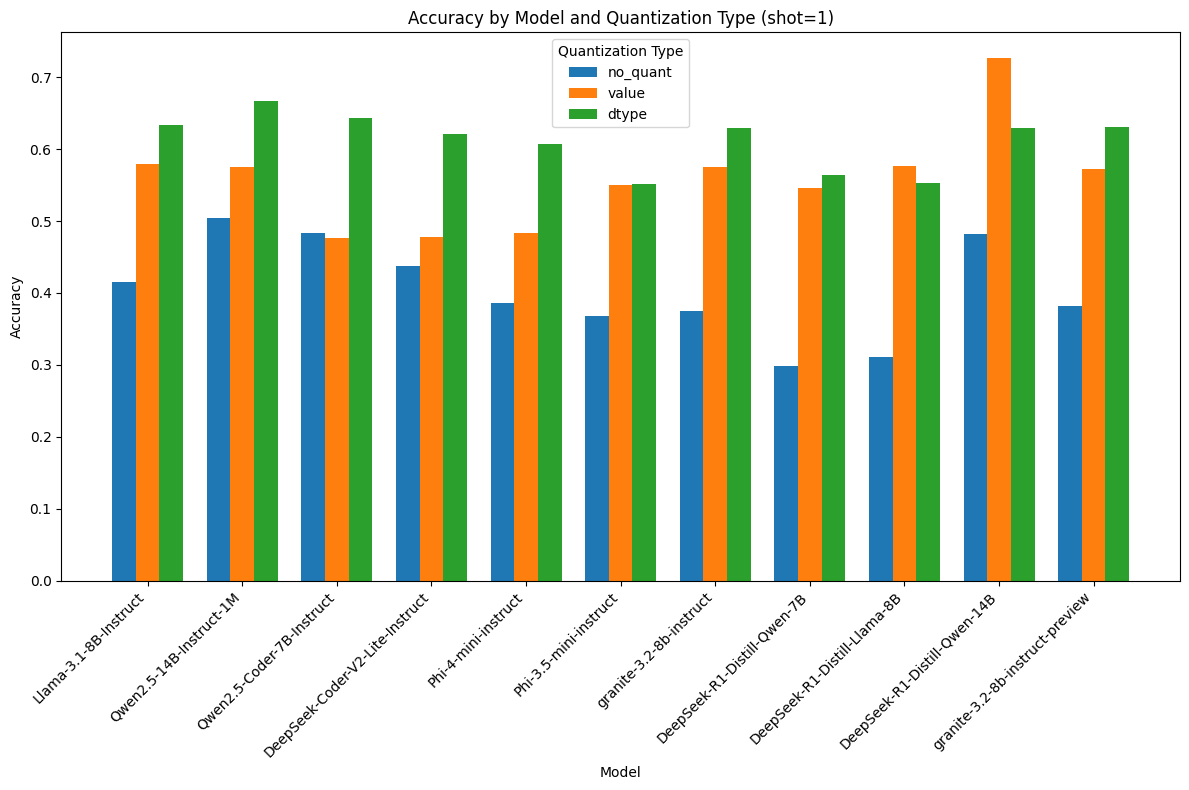

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = "/home/monoshi/CodeSemantic/CodeSemantic/statement_Accuracy_Results_ICML/statement_python.jsonl"
records = []


with open(file_path, 'r') as f:
    for line in f:
        records.append(json.loads(line.strip()))

df = pd.DataFrame(records)


df['quantization_type'] = df['quantization_type'].replace('None', 'no_quant')
shot_1_df = df[df['shot'] == 1]


models = shot_1_df['Model'].unique()
quant_types = ['no_quant', 'value', 'dtype']
model_positions = np.arange(len(models))
width = 0.25  

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']


for idx, qtype in enumerate(quant_types):
    subset = shot_1_df[shot_1_df['quantization_type'] == qtype]
    

    acc_dict = subset.set_index('Model')['accuracy'].to_dict()
    accuracies = [acc_dict.get(model, 0) for model in models]
    

    offset = (idx - 1) * width
    ax.bar(model_positions + offset, accuracies, width, label=qtype, color=colors[idx])


ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Model and Quantization Type (shot=1)')

ax.set_xticks(model_positions)
ax.set_xticklabels(models, rotation=45, ha='right')

ax.legend(title="Quantization Type")
plt.tight_layout()
plt.show()

In [1]:
import json

file_path = '/home/monoshi/CodeSemantic/CodeSemantic/dataset/statement_prediction_dataset_new.jsonl'

with open(file_path, 'r') as f:
    for line in f:
        data = json.loads(line)

        stmt_type = data.get('Statement Type', 'N/A')

        #if stmt_type == 'API':
        
        print("-" * 50)
        print(f"Index: {data.get('idx')}")
        print(f"Type:  {data.get('Statement Type')}")
        print(f"Selected Statement: {data.get('Selected Statement')}")


        print("\nSource Code Snippet:")
        print(data.get('Source Code', '').strip())
        print("-" * 50 + "\n")

        print(f"Value Before: {data.get('Variable Values Before Statement')}")
        print(f"Value After:  {data.get('Value After Statement Execution')}")
        

--------------------------------------------------
Index: 1
Type:  Assignment
Selected Statement: error_msg = 'No client found for name %s' % client_name

Source Code Snippet:
def client_factory(client_name, **kwargs):
    """Return a client for an external data set"""
    # set up
    dir_name = os.path.dirname(os.path.abspath(__file__))
    error_msg = 'No client found for name %s' % client_name
    client_key = client_name.upper()

    # find client
    try:
        client_vals = BALANCING_AUTHORITIES[client_key]
        module_name = client_vals['module']

        class_name = client_vals['class']
    except KeyError:
        raise ValueError(error_msg)

    # find module
    try:
        fp, pathname, description = imp.find_module(module_name, [dir_name])
    except ImportError:
        raise ValueError(error_msg)

    # load
    try:
        mod = imp.load_module(module_name, fp, pathname, description)
    finally:
        # Since we may exit via an exception, close fp explicitly

In [3]:
import json

file_path = '/home/monoshi/CodeSemantic/CodeSemantic/dataset/incremental_statement_prediction_python.jsonl'

with open(file_path, 'r') as f:
    for line in f:
        data = json.loads(line)

        # stmt_type = data.get('Statement Type', 'N/A')

        # if stmt_type == 'API':
        
        print("-" * 50)
        print(f"Index: {data.get('idx')}")
        #print(f"Type:  {data.get('Statement Type')}")
        print(f"Selected Statement: {data.get('Selected Statement')}")


        print("\nSource Code Snippet:")
        print(data.get('Source Code', '').strip())
        print("-" * 50 + "\n")

        print(f"Value Before: {data.get('Variable Values Before Statement')}")
        print(f"Value After:  {data.get('Value After Statement Execution')}")

--------------------------------------------------
Index: 0
Selected Statement: cwd = os.getcwd()

Source Code Snippet:
def secrets_dir(env=os.getenv('D2_ENVIRONMENT', None),
                basedir=os.getenv('D2_SECRETS_BASEDIR', None)):
    if env is not None:
        env_str = str(env)
    else:
        cwd = os.getcwd()
        default_file = os.path.join(cwd, '.python_secrets_environment')
        if os.path.exists(default_file):
            with open(default_file, 'r') as f:
                env_str = f.read().strip()
        else:
            env_str = os.path.basename(cwd)
    if basedir is None:
        basedir = os.path.join(
                HOME,
                'secrets' if sys.platform.startswith('win') else '.secrets')
    return os.path.join(basedir, env_str)
secrets_dir(env=None, basedir=None)
--------------------------------------------------

Value Before: None
Value After:  '/local/rcs/jinjun/code/pytrace-collector/logs/pypibugs/tried/davedittrich+python_secrets/daved